# Chapter 2: Bayesian Computation
## Diagnosing the sampling process

- Once a Bayesian model has been fitted, it is important to evaluate whether the sampling procedure has performed adequately.
- A range of diagnostic tools, both visual and quantitative can be used to detect potential issues in the generated samples.
- Although these methods cannot confirm that the exact posterior distribution has been obtained, they offer useful indications of whether the samples are reliable.
- When potential problems are identified, steps such as increasing the number of samples, improving model specification or choosing a more suitable sampling algorithm may be necessary to obtain more reliable results.

### Example 

- We now revisit the coin-flipping problem using a Bayesian computational approach.
- The first step is to generate or load the data. Here, we use synthetic data so that the true parameter value is known in advance. This allows us to compare the estimated posterior with the actual value of the probability of success, denoted as $\theta_{real}$.
- In real-world applications, this true value is unknown and is precisely what we aim to infer from the data.


In [2]:
import numpy as np
from scipy import stats

np.random.seed(123)

n_experiments = 4
theta_real = 0.35  # true probability of success (unknown in real problems)

data = stats.bernoulli.rvs(p=theta_real, size=n_experiments)

print(data)

[1 0 0 0]


### Model specification

- Now that the data has been generated, we proceed to specify the Bayesian model. In Bayesian analysis, model specification is done by defining two key components: the **prior distribution** and the **likelihood function**, both expressed using probability distributions.

   - The prior distribution represents our belief about the unknown parameter before observing the data.
   - The likelihood function describes how the observed data is generated given the parameter.

### Prior distribution

We assume the unknown probability of success $\theta$ follows a Beta distribution:

$$\theta \sim \text{Beta}(\alpha = 1, \beta = 1)$$

- The Beta(1,1) distribution is equivalent to a Uniform(0,1) distribution.
- This means we assign equal probability to all values of θ between 0 and 1.
In other words, we are using a **non-informative prior**, indicating no prior preference for any specific value of the parameter.

### Likelihood function

- Since the observed data consists of binary outcomes (0/1), each observation is modeled using a Bernoulli distribution:

$$y∼\text{Bernoulli}(\theta)$$

- The Bernoulli distribution can also be viewed as a special case of the Binomial distribution:

   - $\text{Bernoulli}(\theta)≡\text{Binomial}(n=1,\theta)$
   - This means each experiment represents a single trial with success probability $\theta$.

### Full Bayesian model

- Combining prior and likelihood, the complete model is:

$$\theta ∼ \text{Beta}(1,1), y∼ \text{Bernoulli}(\theta)$$

This expresses the idea that we are learning about an unknown probability $\theta$ using observed binary data, starting from a completely non-informative prior.

In PyMC, the model is defined inside a with block, where all probabilistic components belong to the same model context.

In [4]:
import pymc as pm

with pm.Model() as our_first_model:
    
    # Prior distribution for theta (Uniform via Beta(1,1))
    theta = pm.Beta("theta", alpha=1, beta=1)
    
    # Likelihood: Bernoulli observations (equivalent to Binomial(n=1))
    y = pm.Bernoulli("y", p=theta, observed=data)

- For this simple coin-flipping problem, the posterior distribution is actually available in closed form. However, we can also perform Bayesian inference computationally using PyMC (v5) in just a few lines of code.

- We now implement Bayesian inference using two different sampling approaches to estimate the posterior distribution of $\theta$: NUTS (the default modern sampler) and Metropolis-Hastings (a more basic, general-purpose sampler). Both methods target the same posterior but differ in how efficiently they explore it.

#### NUTS (default sampler)

In [10]:
import pymc as pm

with pm.Model() as model_nuts:
    
    # Prior
    theta = pm.Beta("theta", alpha=1, beta=1)
    
    # Likelihood
    y = pm.Bernoulli("y", p=theta, observed=data)

    # Inference using NUTS (default)
    trace_nuts = pm.sample(1000, tune=1000, chains=1, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [theta]


C:\Users\B1500\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 1 chain for 1_000 tune and 1_000 draw iterations (1_000 + 1_000 draws total) took 7 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


- NUTS is the default sampler in PyMC for continuous parameters.
- It automatically adapts step sizes and trajectory lengths.
- It is typically more efficient and requires no manual configuration.

####  Metropolis-Hastings sampler

In [11]:
with pm.Model() as model_mh:
    
    # Prior
    theta = pm.Beta("theta", alpha=1, beta=1)
    
    # Likelihood
    y = pm.Bernoulli("y", p=theta, observed=data)

    # Explicit Metropolis sampler
    step = pm.Metropolis()
    trace_mh = pm.sample(1000, step=step, tune=1000, chains=1, return_inferencedata=True)

Sequential sampling (1 chains in 1 job)
Metropolis: [theta]


C:\Users\B1500\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 1 chain for 1_000 tune and 1_000 draw iterations (1_000 + 1_000 draws total) took 3 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


- Both approaches approximate the same posterior distribution:
$$p(\theta∣y)$$
    
- Metropolis-Hastings generates candidate values and accepts or rejects them.
- It is more general but often mixes more slowly than NUTS.
- It is useful for understanding basic MCMC concepts and for comparison.

### Diagnosing the sampling process

- Since the posterior distribution is approximated using a finite number of samples, it is important to evaluate whether this approximation is reliable.
- In practice, we use a variety of diagnostic tools to assess the quality of the sampled output.
- These methods can be either visual (such as trace plots) or quantitative (such as convergence diagnostics and effective sample size).
- It is important to emphasize that these diagnostics cannot prove that we have obtained the true posterior distribution. Instead, they provide evidence on whether the samples are a reasonable approximation of it.
- If problems are detected in the sampling process, common remedies include:

#### Increase the number of samples
- A larger number of draws generally improves the accuracy of the posterior approximation and reduces Monte Carlo error.

#### Remove early samples (burn-in / tuning phase)
- MCMC algorithms often require an initial period to stabilize before reaching the target distribution.
- Samples generated during the initial phase of the algorithm are typically discarded, as this period—known as the **warm-up phase** (also called **tuning**, or **burn-in** in the earlier literature)
- This is used for the sampler to adapt, stabilize, and converge toward the target distribution before drawing samples used for inference.
-  Although not required in the theoretical formulation of Markov chains, it is a practical adjustment used when working with finite samples.
-  It is important not to confuse the mathematical ideal (an infinite Markov chain) with its finite computational approximation.
-  In practice, we only observe a finite trajectory, and discarding early samples helps reduce initialization effects.

#### Reparameterize the model
- The same model can often be expressed in an alternative but mathematically equivalent form.
- A better parameterization can improve geometry and lead to faster and more stable sampling.

#### Transform the data
- Applying transformations (e.g., scaling or log transforms) can significantly improve sampling efficiency.
- When doing so, care must be taken to interpret results correctly in the transformed space or to invert the transformation before drawing conclusions.

We will revisit each of these strategies in more detail throughout this course, as they play a crucial role in practical Bayesian computation.

## Convergence

- The first step in diagnosing the sampling process is to visually inspect the results to assess whether the Markov chains appear to have converged.
- A commonly used tool for this purpose is the trace plot, which displays both the sampled values over iterations and the corresponding posterior density.
- To reduce the effect of the initial warm-up phase (also called tuning or burn-in in earlier literature), we discard the first set of samples before analysis. The remaining samples are then used for diagnostics and inference.

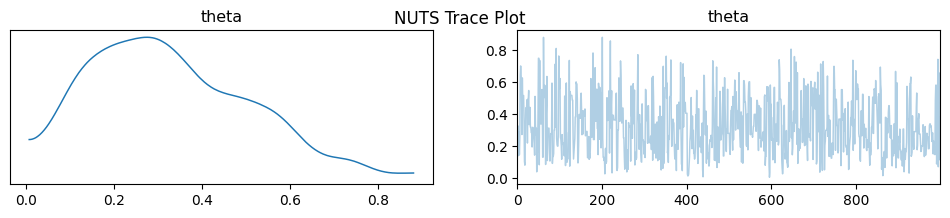

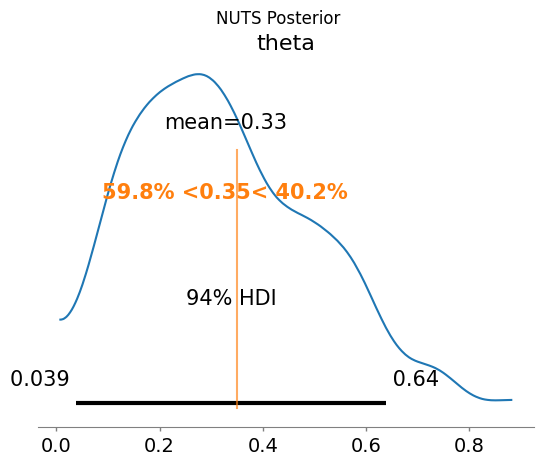

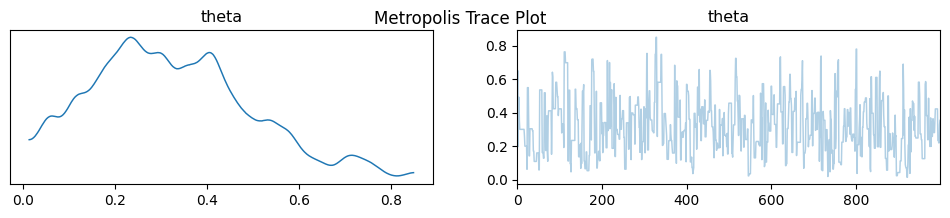

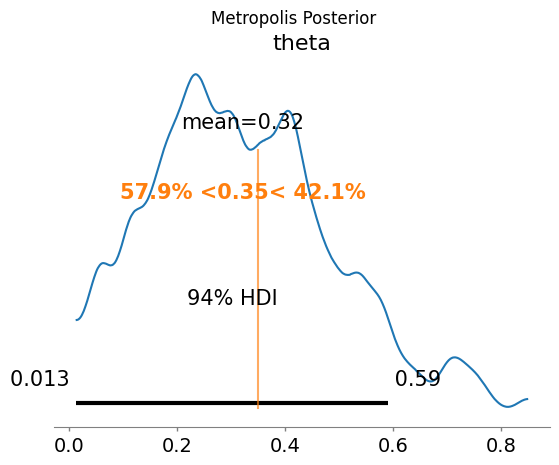

In [12]:
#  ArviZ for Bayesian diagnostics and visualization of posterior samples
# Matplotlib for controlling and displaying plots.
import arviz as az
import matplotlib.pyplot as plt

# -------------------------
# NUTS plots
# -------------------------
az.plot_trace(trace_nuts)
plt.suptitle("NUTS Trace Plot")
plt.show()

az.plot_posterior(trace_nuts, ref_val=theta_real)
plt.suptitle("NUTS Posterior")
plt.show()

# -------------------------
# Metropolis plots
# -------------------------
az.plot_trace(trace_mh)
plt.suptitle("Metropolis Trace Plot")
plt.show()

az.plot_posterior(trace_mh, ref_val=theta_real)
plt.suptitle("Metropolis Posterior")
plt.show()

- For each unobserved variable, ArviZ provides three key diagnostic views of the posterior distribution:

  - A kernel density estimate (KDE) plot showing the shape of the posterior distribution
  - A trace plot showing how sampled values evolve across iterations
  - A Highest Density Interval (HDI) representing the most credible range of parameter values

- Together, these plots provide both a visual and quantitative summary of the posterior distribution.

- When interpreting posterior diagnostic plots, we focus on these three main components: the KDE plot, the trace plot, and the HDI (Highest Density Interval). Each provides a different view of how well the sampler has approximated the posterior distribution.

- The KDE (kernel density estimate) plot should represent a smooth curve, which is a smoothed approximation of the posterior distribution. It helps us understand the location, spread, and shape of uncertainty in the parameter. Often, as the amount of data increases, the distribution of each parameter tends to become Gaussian-like. This behavior is related to the law of large numbers and asymptotic properties of Bayesian inference, although it is not guaranteed in all models.

- The trace plot shows the sampled values over MCMC iterations. A well-behaved trace should look like white noise, indicating good mixing. We should not observe any recognizable patterns such as upward or downward trends. Instead, the chain should fluctuate randomly around a single stable value, effectively meandering around a constant level.

- If the first part of the trace looks different than the others this is an indication of the  need for burnin. If we see a lack of auto-similarity in other parts or we see some pattern this is an indication for more steps, or the need to use a different sampler or  a different parametrization. For difficult models, we may apply a combination of all these strategies.

- For multimodal or discrete distributions, we expect the sampler not to remain in a single region for too long. Instead, it should move freely between regions of high probability, reflecting good exploration of the posterior space.

- Another important property is auto-similarity (stationarity) of the trace. This means that different parts of the chain should look statistically similar; for example, the first 10% of samples should resemble later portions such as the last 50% or 10%. A well-mixed chain does not show structural changes over time.

- The HDI (Highest Density Interval) provides the range of most credible values of the parameter. For example, a 94% HDI contains the most probable 94% of the posterior mass. A well-converged posterior should show a stable HDI centered around the main posterior mass, summarizing the uncertainty in a meaningful way.

- In the coin flip example, both NUTS and Metropolis-Hastings target the same posterior distribution, and in this example they produce similar central estimates for the parameter $\theta$ (approximately 0.33 for NUTS and 0.32 for Metropolis), which are close to the true value $\theta_{real}=0.35$. This indicates that both methods are, in principle, correctly recovering the posterior distribution.

- However, important differences can be observed in their behavior. The NUTS sampler produces a smooth and well-behaved posterior distribution, with a stable trace and a unimodal KDE, indicating efficient exploration of the parameter space.

- In contrast, the Metropolis sampler shows a more irregular posterior shape, and in this case, the KDE appears slightly bimodal or less smooth. This behavior is typically a sign of poorer mixing and less efficient exploration, especially in small datasets where the posterior is relatively flat or weakly informed.

### Parallel chains in modern PyMC

- In modern PyMC, models are typically run using multiple independent MCMC chains in parallel by default.
- This is done to improve convergence diagnostics and reliability of the inference, since comparing multiple chains helps us verify that they have all converged to the same posterior distribution rather than being stuck in different regions of the parameter space.
- Each chain is initialized separately and samples the same posterior distribution. This allows us to assess convergence more reliably, since all chains should converge to the same target distribution.
- If convergence has been achieved, all chains should look statistically similar and exhibit comparable behavior.
- These parallel chains are not discarded. Instead, they are combined automatically during inference to increase the effective sample size and improve posterior estimation.

In [14]:
with pm.Model() as model_nuts:
    
    # Prior
    theta = pm.Beta("theta", alpha=1, beta=1)
    
    # Likelihood
    y = pm.Bernoulli("y", p=theta, observed=data)

    # Inference using NUTS with multiple parallel chains
    trace_nuts = pm.sample(
        1000,
        tune=1000,
        chains=4,              # parallel chains (default is often 4)
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


C:\Users\B1500\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 43 seconds.


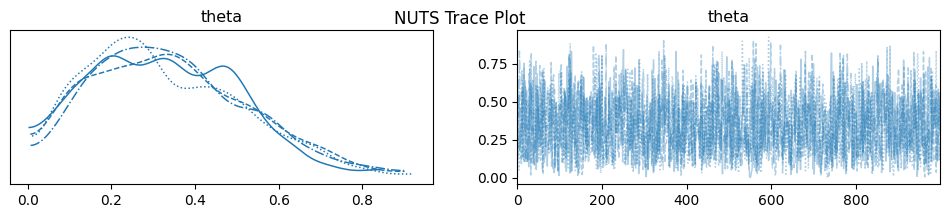

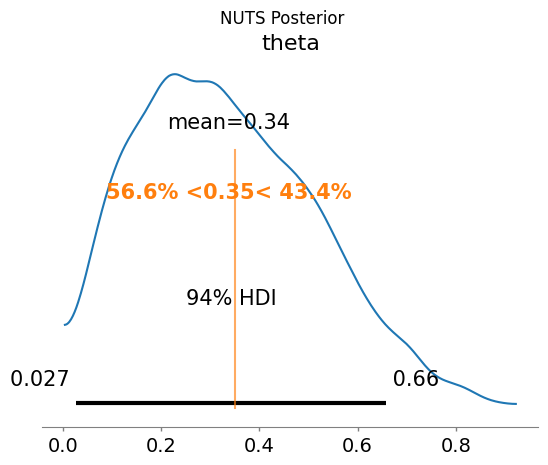

In [16]:
az.plot_trace(trace_nuts)
plt.suptitle("NUTS Trace Plot")
plt.show()

az.plot_posterior(trace_nuts, ref_val=theta_real)
plt.suptitle("NUTS Posterior")
plt.show()


Multiprocess sampling (4 chains in 4 jobs)
Metropolis: [theta]


C:\Users\B1500\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 31 seconds.


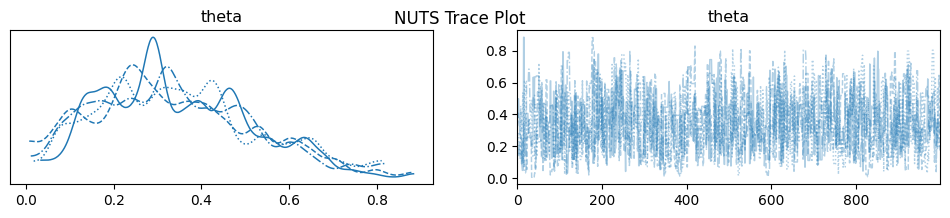

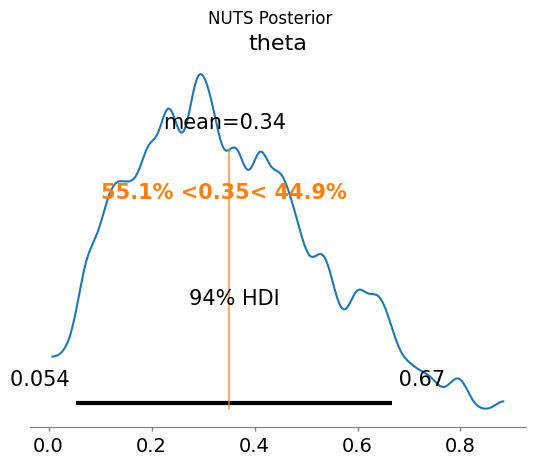

In [33]:
with pm.Model() as model_mh:
    
    theta = pm.Beta("theta", alpha=1, beta=1)
    y = pm.Bernoulli("y", p=theta, observed=data)

    step = pm.Metropolis()

    trace_mh = pm.sample(
        1000,
        tune=1000,
        step=step,
        chains=4,
        return_inferencedata=True
    )

az.plot_trace(trace_mh)
plt.suptitle("NUTS Trace Plot")
plt.show()

az.plot_posterior(trace_mh, ref_val=theta_real)
plt.suptitle("NUTS Posterior")
plt.show()

- In the NUTS results, the trace plot shows that all chains are closely aligned and fluctuate around the same stable region, indicating strong agreement between chains and good convergence.The posterior density is smooth and approximately Gaussian-shaped, suggesting efficient exploration of the parameter space with low autocorrelation and well-mixed samples.

- In contrast, the Metropolis-Hastings results show more visible differences between chains in the trace plot, indicating slower mixing and higher dependence between successive samples. The corresponding posterior density is less smooth and slightly irregular, reflecting less efficient sampling and weaker exploration of the posterior distribution compared to NUTS.

### Gelman–Rubin diagnostic (R-hat)

- A quantitative way to assess convergence is the Gelman–Rubin diagnostic, also known as $\hat{R}$.
- The idea is to compare the variance between chains with the variance within each chain. If all chains have converged to the same posterior distribution, these variances should be very similar.

- In practice, we require multiple MCMC chains for this diagnostic to be meaningful.

  - Ideal value: $\hat{R} = 1$
  - Practical guideline: $\hat{R}$ between  1.01 and 1.1 → acceptable convergence
- Larger values indicate possible convergence problems

- In modern PyMC, R-hat is computed using ArviZ.

In [19]:
# R-hat (Gelman-Rubin diagnostic)
az.rhat(trace_nuts)

<xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    theta    float64 8B 1.001
Attributes:
    created_at:                 2026-04-27T17:16:05.718173+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.4
    sampling_time:              43.39294648170471
    tuning_steps:               1000

- The computed R-hat value for the parameter $\theta$ is  $\hat{R}=1.001$

- This value is extremely close to 1, which indicates that the multiple MCMC chains have successfully converged to the same target distribution. In other words, the variation between chains is almost identical to the variation within each chain.

- Since values of  $\hat{R}$ close to 1 suggest good convergence, this result provides strong evidence that the sampler (in this case NUTS) has adequately explored the posterior distribution and that the inference is reliable.

In [20]:
# R-hat (Gelman-Rubin diagnostic)
az.rhat(trace_mh)

Multiprocess sampling (4 chains in 4 jobs)
Metropolis: [theta]


C:\Users\B1500\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 38 seconds.


<xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    theta    float64 8B 1.005
Attributes:
    created_at:                 2026-04-27T17:30:10.861611+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.4
    sampling_time:              38.231462717056274
    tuning_steps:               1000

- For the Metropolis-Hastings sampler, the R-hat value for the parameter $\theta$ is $\hat{R}=1.005$

- This value is slightly larger than the NUTS result but still very close to 1. This indicates that the multiple MCMC chains are largely consistent with each other and have approximately converged to the same posterior distribution.

- However, compared to the NUTS sampler, the value being slightly further from 1 suggests that Metropolis-Hastings mixes less efficiently, meaning the chains take longer or explore the posterior space less smoothly.

- In general:
  - $\hat{R} \approx 1$ → good convergence
  - $\hat{R} > 1.1$→ problematic convergence

- Therefore, $\hat{R}=1.005$ still indicates acceptable convergence, but with slightly weaker efficiency compared to NUTS, which is consistent with the known behavior of Metropolis-Hastings in simple models.

#### Forest plot ( posterior summary)

- We can also visualize the R-hat value together with summary statistics of the posterior distribution for each parameter using a forest plot. This plot combines both convergence diagnostics and uncertainty quantification in a single figure.

- It typically shows:

  - the posterior mean
  - the credible interval (HDI, e.g. 95%)
  - the $\hat{R}$ value for each parameter

- This allows a compact comparison of both estimation uncertainty and convergence quality.

array([<Axes: title={'center': '95.0% HDI'}>], dtype=object)

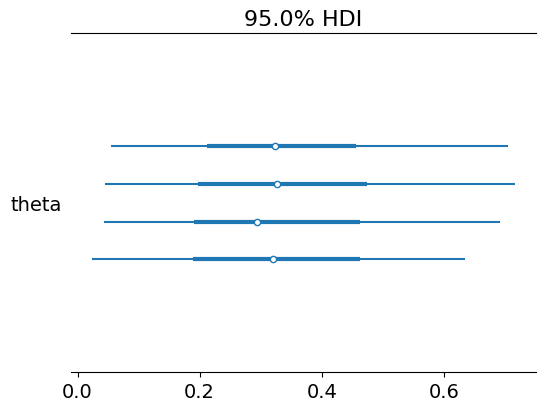

In [21]:
az.plot_forest(
    trace_nuts,
    var_names=["theta"],
    hdi_prob=0.95
)

In this version of the forest plot, each MCMC chain is displayed separately. Since the model uses 4 independent chains, we observe four horizontal intervals for the same parameter θ.

Each line represents:
  - the posterior mean from a single chain
  - the 95% HDI estimated from that chain

- All chains should give similar estimates of $\theta$
- If the intervals overlap strongly, it indicates good convergence
- Differences between chains reflect sampling variability, not different parameters

- This view is mainly useful for diagnosing convergence visually across chains.

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

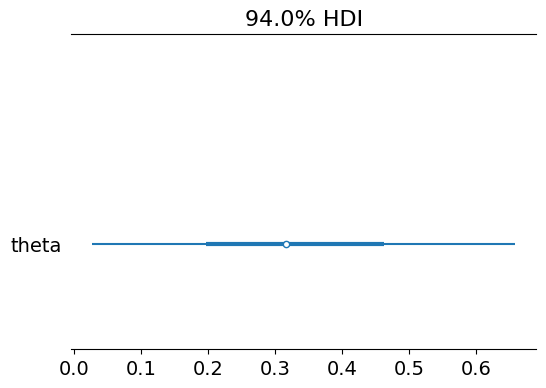

In [22]:

az.plot_forest(
    trace_nuts,
    var_names=["theta"],
    combined=True
)

- In this version, all chains are pooled together into a single posterior distribution. The forest plot now shows one summary line for $\theta$.

- This line represents:
  - the combined posterior mean
  - the overall 95% HDI using all samples

- This is the final Bayesian inference result
- It ignores chain structure and treats all samples as one dataset
- It provides a cleaner summary of posterior uncertainty

The function `az.summary()` provides a text-based summary of the posterior distribution. It is a convenient way to quickly inspect key numerical characteristics of the inference results.

In [23]:
az.summary(trace_nuts, hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta,0.337,0.181,0.029,0.685,0.004,0.002,1692.0,2106.0,1.0


In [24]:
az.summary(trace_mh, hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta,0.326,0.176,0.017,0.652,0.006,0.004,917.0,841.0,1.0


The ArviZ summary table provides both posterior characteristics (what we learn about the parameter) and sampling diagnostics (how reliable the simulation is).

1. Posterior mean and standard deviation
   - NUTS: mean ≈ 0.337, sd ≈ 0.181
   - Metropolis: mean ≈ 0.326, sd ≈ 0.176

- Both methods produce similar posterior means and both are reasonably close to the true value $\theta =0.35$.
- However, they are not exactly equal to the true value, which is expected in Bayesian inference.

- In Bayesian analysis, we do not aim to recover the exact parameter value. Instead, we estimate a posterior distribution that represents uncertainty about the parameter given limited data and prior information.

- The small differences in the mean and standard deviation arise due to:
    - the very small dataset (only 4 observations)
    - the influence of the prior distribution
    - Monte Carlo sampling variability


2. HDI (Highest Density Interval)
   - NUTS 95% HDI: [0.029, 0.685]
   - Metropolis 95% HDI: [0.017, 0.652]

- Both methods produce wide and overlapping credible intervals, indicating high uncertainty in the posterior due to the small sample size.
- Importantly, the true value $\theta = 0.35$ lies within both intervals, meaning both models are consistent with the data-generating process.

3. MCSE (Monte Carlo Standard Error)
   - NUTS: MCSE_mean ≈ 0.004
   - Metropolis: MCSE_mean ≈ 0.006

- MCSE measures the small numerical error introduced when we approximate the posterior using a finite number of correlated MCMC samples, and it indicates how much the estimated mean would vary if the sampling process were repeated..
- Both values are small, indicating stable estimates. However, Metropolis shows slightly higher MCSE, meaning its estimates are slightly noisier amd more samples would be needed to reach the same precision as NUTS

4. ESS (Effective Sample Size)
   - NUTS: ESS ≈ 1692 (bulk), 2106 (tail)
   - Metropolis: ESS ≈ 917 (bulk), 841 (tail)


- Effective Sample Size measures how many independent samples your correlated MCMC draws are equivalent to.
- even though we generate 4000 total samples (4 chains × 1000 samples per chain), the ESS is usually smaller due to autocorrelation between samples in the MCMC chain, meaning they do not all carry unique information.
- NUTS has a much higher ESS, meaning better mixing, lower autocorrelation, more efficient exploration of the posterior
- Metropolis has lower ESS, indicating stronger dependence between samples and slower mixing.
- If ESS ≈ total samples → very efficient sampling (low autocorrelation)
- If ESS << total samples → strong autocorrelation and inefficient sampling
- Practical guidelines
    - ESS ≥ 100 → sufficient for estimating means
    - ESS ≥ 1000 → needed for reliable tail estimates (e.g., credible intervals)

5. $\hat{R}$ (Gelman–Rubin diagnostic)
   - NUTS: $\hat{R}$  ≈ 1.0
   - Metropolis: $\hat{R}$  ≈ 1.0

- $\hat{R}$  measures convergence across multiple chains by comparing within-chain and between-chain variability.
- Both values being approximately 1 indicates, all chains have converged and chains are consistent with each other and posterior sampling is reliable
- However, $\hat{R}$  does not measure efficiency, only convergence.

Both samplers correctly estimate the posterior distribution, but NUTS provides a more efficient and stable approximation, especially in terms of effective sample size and Monte Carlo error, while Metropolis-Hastings requires more samples to achieve similar accuracy.

## Autocorrelation

- In an ideal Bayesian simulation, each MCMC sample would be independent of the others, meaning there would be no relationship between values at different iterations.
- In practice, however, MCMC methods—especially Metropolis-Hastings—produce samples that can be autocorrelated, where each draw is partially dependent on previous draws.
- Autocorrelation can also arise from the structure of the model, particularly when parameters are strongly related to each other.

array([<Axes: title={'center': 'theta\n0'}>,
       <Axes: title={'center': 'theta\n1'}>,
       <Axes: title={'center': 'theta\n2'}>,
       <Axes: title={'center': 'theta\n3'}>], dtype=object)

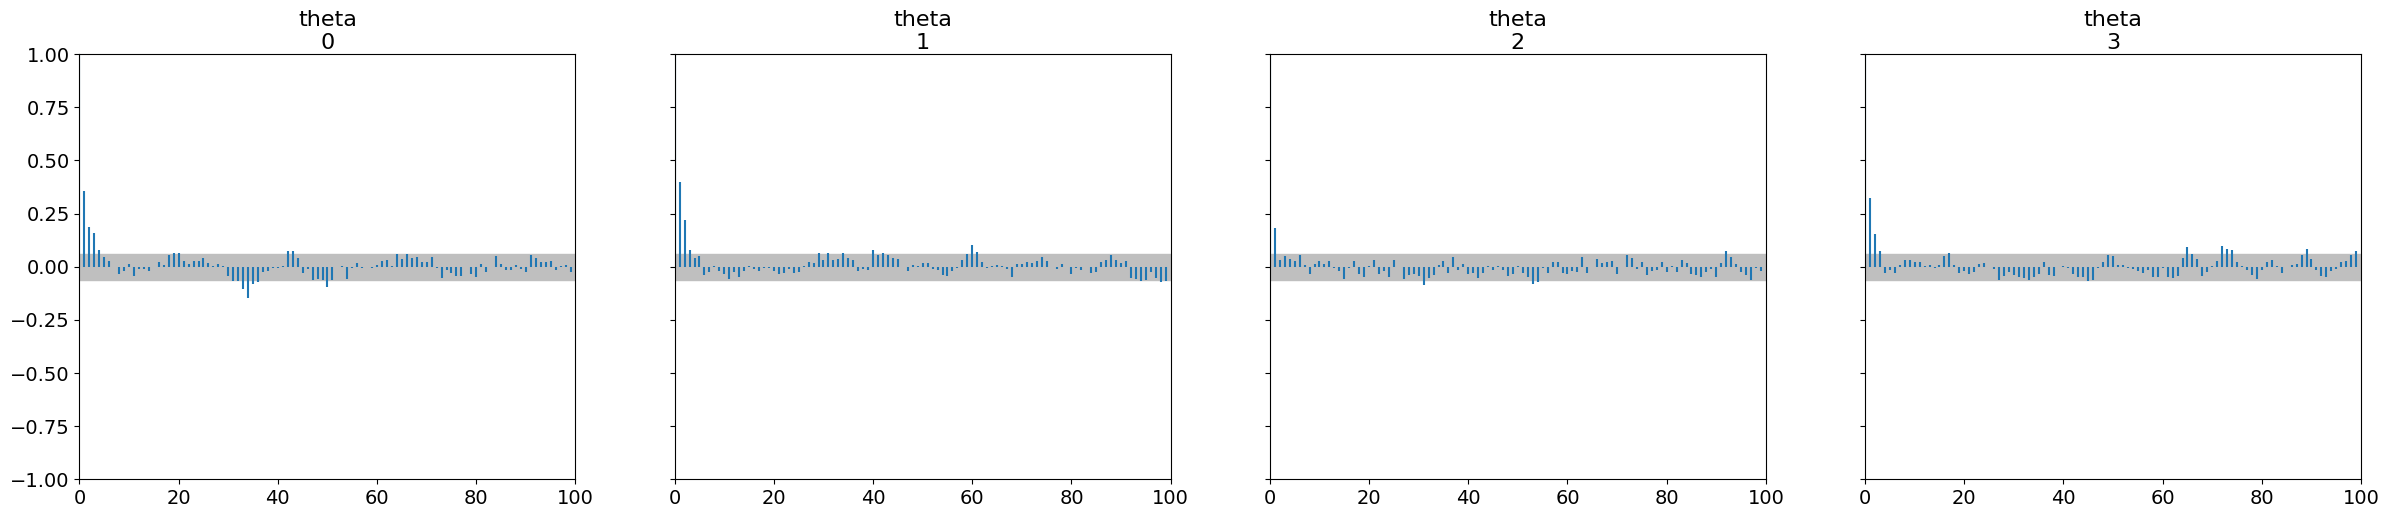

In [39]:
az.plot_autocorr(
    trace_nuts,
    var_names=["theta"]
)

<Axes: title={'center': 'theta'}>

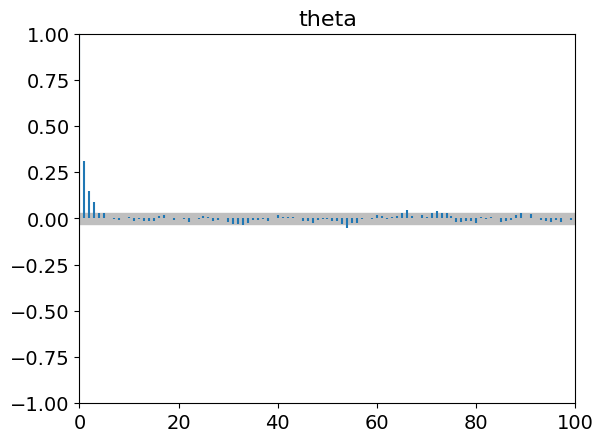

In [26]:
az.plot_autocorr(
    trace_nuts,
    var_names=["theta"],
    combined=True
)

array([<Axes: title={'center': 'theta\n0'}>,
       <Axes: title={'center': 'theta\n1'}>,
       <Axes: title={'center': 'theta\n2'}>,
       <Axes: title={'center': 'theta\n3'}>], dtype=object)

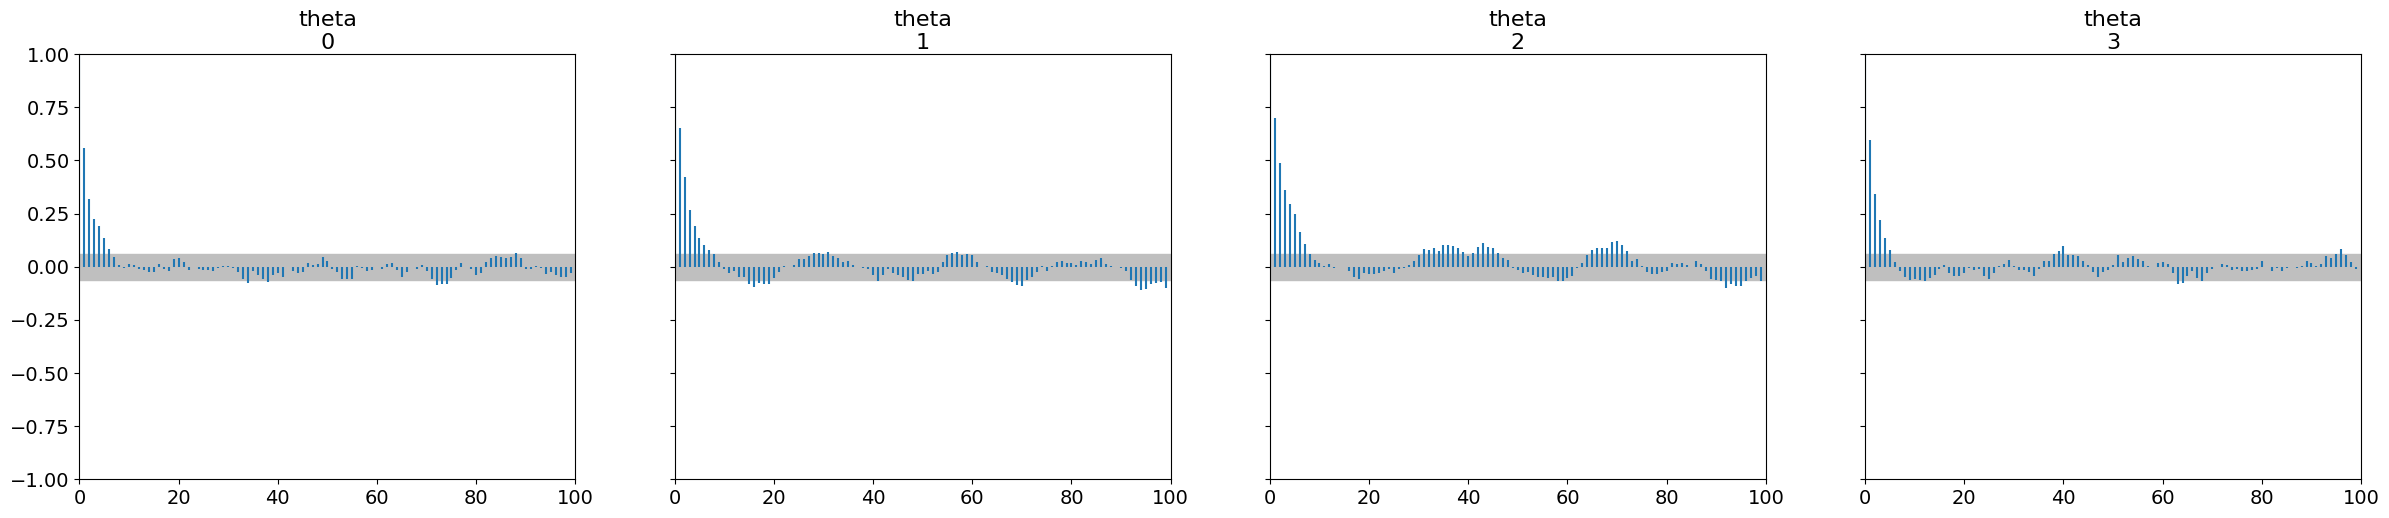

In [40]:
az.plot_autocorr(
    trace_mh,
    var_names=["theta"]
)

<Axes: title={'center': 'theta'}>

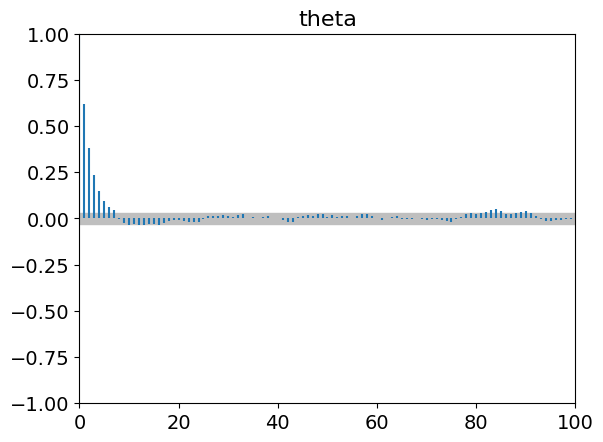

In [29]:
az.plot_autocorr(
    trace_mh,
    var_names=["theta"],
    combined=True
)

- Setting `combined=True` merges all MCMC chains into a single sequence, producing one autocorrelation plot that reflects the overall sampling dependence rather than chain-specific behavior.
- In an ideal case, autocorrelation should be close to zero at all lags, meaning samples are effectively independent.
- In practice, we want autocorrelation to drop quickly toward zero as the lag increases.
- If autocorrelation remains high across many lags, it indicates that the chain is moving slowly and producing similar values over time.
- NUTS shows autocorrelation that drops to near zero within the first few lags (around 3), indicating fast mixing and nearly independent samples, whereas Metropolis-Hastings retains significant autocorrelation for about 7 lags, showing slower mixing and more dependent samples.

## Summarizing the posterior

- The result of a Bayesian analysis is a posterior distribution, which fully describes our updated knowledge about the parameter after observing the data.
-  Instead of giving a single value, it represents a range of plausible values with associated probabilities.

<Axes: title={'center': 'theta'}>

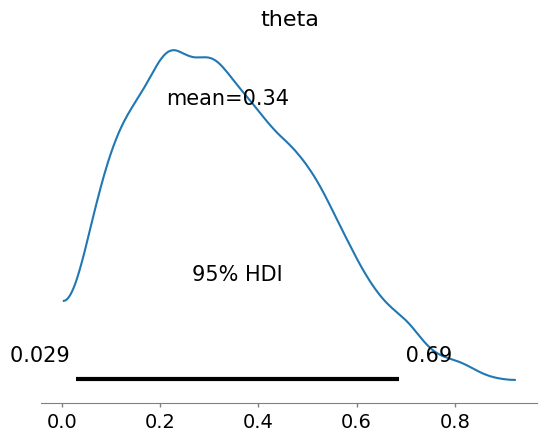

In [30]:

az.plot_posterior(
    trace_nuts,
    var_names=["theta"],
    hdi_prob=0.95
)

<Axes: title={'center': 'theta'}>

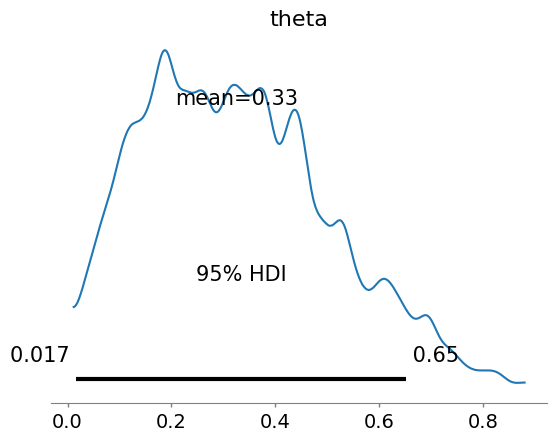

In [31]:

az.plot_posterior(
    trace_mh,
    var_names=["theta"],
    hdi_prob=0.95
)

- This plot provides a compact summary of the posterior distribution
- The smooth curve shows the posterior density of the parameter
- It helps us understand:
   - where the parameter is concentrated
   - how uncertain it is
   - whether the distribution is symmetric or skewed
     
- The shaded interval (e.g., 95% HDI) shows the most credible range of values--> Highest Density Interval
- It contains the region where the parameter is most likely to lie, given the data
- Example - A 95% HDI means that 95% of the posterior probability mass is concentrated within this interval.

- In this exmaple, NUTS produces a smoother, more Gaussian-like posterior due to efficient Hamiltonian exploration of the parameter space, while Metropolis-Hastings can produce a noisier and less stable posterior shape due to slower and more correlated sampling

## Posterior-based decisions

- In many Bayesian problems, describing the posterior distribution is not enough—we often need to make a decision based on it. This usually means converting a continuous estimate into a binary decision, such as fair vs not fair, safe vs unsafe, or acceptable vs not acceptable.

- In this coin-flipping example, we may want to decide whether the coin is fair, where a fair coin corresponds to θ=0.5. However, in a strict mathematical sense, the probability of θ being exactly 0.5 is essentially zero in a continuous model. Therefore, in practice, we define fairness as a region around 0.5, where “around” depends on the context and decision tolerance.

- A natural way to support this decision is by using the Highest Density Interval (HDI). If the HDI includes 0.5, it means that plausible values of θ supported by the data still include the possibility of a fair coin. In your result, the 95% HDI spans approximately from 0.06 to 0.71, which clearly includes 0.5.

- This leads to a careful interpretation: although the posterior mean may suggest some bias (e.g., slightly tail-biased), the uncertainty is still large enough that we cannot confidently rule out fairness. To make a stronger decision, we would typically need more data to reduce posterior uncertainty, or we could incorporate more domain knowledge through a more informative prior.

## ROPE (Region Of Practical Equivalence)

-A ROPE is a simple way to make decisions from a posterior distribution when exact equality is not meaningful in practice.
- Instead of asking whether a parameter is exactly equal to a value (for example, θ=0.5), we define a small interval around that value where differences are considered practically unimportant. Any value inside this interval is treated as essentially the same as the reference value.

- For a coin-flipping problem, we may define: ROPE=[0.45,0.55], meaning values of θ in this range are considered practically equivalent to a fair coin (θ=0.5).

<Axes: title={'center': 'theta'}>

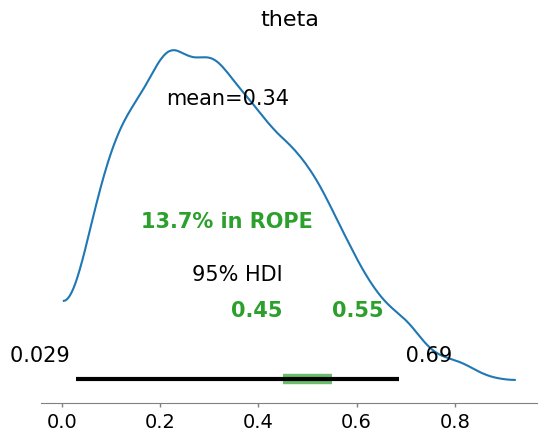

In [34]:
az.plot_posterior(
    trace_nuts,
    var_names=["theta"],
    rope=[0.45, 0.55],
    hdi_prob=0.95
)

<Axes: title={'center': 'theta'}>

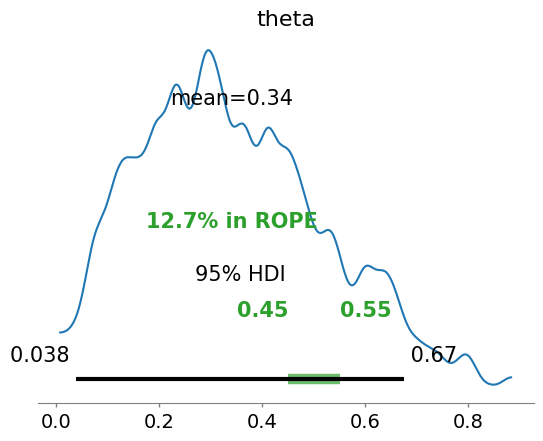

In [35]:
az.plot_posterior(
    trace_mh,
    var_names=["theta"],
    rope=[0.45, 0.55],
    hdi_prob=0.95
)

**Decision rule using ROPE and HDI**

- We compare the ROPE with the HDI (Highest Density Interval) of the posterior distribution:

- **No overlap between ROPE and HDI**
    - All credible values are outside the “practically equal” region
    - The parameter is clearly different from the reference value (coin is not fair)

- **HDI fully inside ROPE**
    - All credible values are practically equivalent to the reference value
    - The parameter is consistent with the reference value (coin is fair)

- **Partial overlap between ROPE and HDI**
    - Some plausible values are inside ROPE and some are outside
    - The data is not strong enough to make a clear decision (inconclusive)


- In this exmaple, both samplers show that only a small portion of the posterior distribution falls within the “practically fair” region, meaning that most of the probability mass lies outside the ROPE.

- This suggests that the data provides some evidence against a perfectly fair coin (θ = 0.5)

- However, the proportion inside the ROPE is still non-zero, meaning there is still some probability that the coin could be practically fair

### Posterior comparison using a reference value

We can also compare the posterior distribution with a specific reference value (for example, θ=0.5)

<Axes: title={'center': 'theta'}>

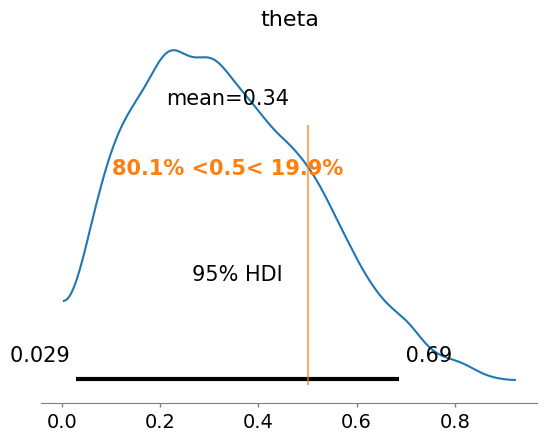

In [36]:
# Posterior plot with reference value
az.plot_posterior(
    trace_nuts,
    var_names=["theta"],
    hdi_prob=0.95,
    ref_val=0.5
)

<Axes: title={'center': 'theta'}>

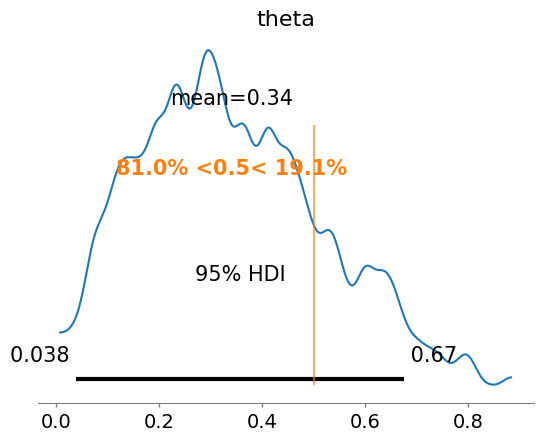

In [38]:
# Posterior plot with reference value
az.plot_posterior(
    trace_mh,
    var_names=["theta"],
    hdi_prob=0.95,
    ref_val=0.5
)

- Both NUTS and Metropolis-Hastings give almost identical results, showing strong agreement between the two samplers.

- In both cases:
   - The majority of posterior probability lies below 0.5
   - This suggests the coin is more likely biased toward tails (θ < 0.5) rather than being perfectly fair
   - However, there is still a non-negligible probability (≈ 19–20%) above 0.5, meaning fairness cannot be completely ruled out